# Radyomik Özelliklerle Papilödem Sınıflandırması
**Yapay Zeka Final Ödevi**

Bu notebook, patient-level radyomik veri ile Normal vs Papilödem ayırımı için geliştirilen pipeline'ın akademik sunumudur.

## 1. Veri Yükleme ve İntegrity Kontrolü

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "Okan_Odev" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from src.data_loader import load_dataset
from src import config

bundle = load_dataset()
print('X shape:', bundle.X.shape)
print('Patients:', len(set(bundle.patient_id)))
uniq, cnt = np.unique(bundle.y, return_counts=True)
print('Class balance:', dict(zip(uniq.tolist(), cnt.tolist())))

X shape: (966, 748)
Patients: 69
Class balance: {0: 672, 1: 294}


C:\Users\gokss\AppData\Local\Temp\ipykernel_10092\2506428506.py:13: UserWarning: Replacing 1 infinity values with NaN for median imputation
  bundle = load_dataset()


**İntegrity assertions** veri yükleme sırasında otomatik çalışır:
1. Hasta sınıflar arası çakışmıyor (`N_*` ve `P_*` setleri disjoint).
2. Her hasta sadece bir sınıf etiketine sahip.
3. Hasta başına örnek sayısı tutarlı.

## 2. Pipeline Çalıştırma
Tam çalıştırma offline yapıldı. Buradan kaydedilmiş sonuçları yüklüyoruz.

In [2]:
import json

summary = pd.read_csv(config.TABLES_DIR / 'metrics_summary.csv', header=[0, 1], index_col=0)
summary

accuracy           precision              recall            \
              mean       std      mean       std      mean       std   
model                                                                  
ET        0.873724  0.052838  0.799545  0.130047  0.816777  0.143822   
Ensemble  0.877806  0.050030  0.810490  0.114151  0.807219  0.185400   
GB        0.866327  0.097335  0.821843  0.112640  0.770451  0.200754   
KNN       0.851020  0.068603  0.790364  0.178831  0.755867  0.165144   
LR        0.829847  0.080113  0.750851  0.205710  0.721412  0.207126   
RF        0.878571  0.045048  0.824489  0.128879  0.787041  0.182131   
SVM       0.872194  0.051274  0.831124  0.151471  0.759328  0.169653   

                f1            macro_f1             roc_auc            \
              mean       std      mean       std      mean       std   
model                                                                  
ET        0.793797  0.095092  0.847226  0.060275  0.943406  0.061807   
Ensemble  0.788820  0.113419  0.846956  0.065731  0.939880  0.065270   
GB        0.773617  0.133751  0.822116  0.136095  0.917873  0.075481   
KNN       0.751623  0.122131  0.818498  0.079126  0.906177  0.075496   
LR        0.709834  0.161226  0.786845  0.097308  0.886987  0.080563   
RF        0.784310  0.118982  0.845560  0.065445  0.937330  0.067230   
SVM       0.775291  0.118797  0.839005  0.069750  0.921675  0.064774   

            pr_auc           balanced_accuracy               brier            
              mean       std              mean       std      mean       std  
model                                                                         
ET        0.917017  0.100868          0.857507  0.067615  0.080518  0.034652  
Ensemble  0.910695  0.100142          0.857268  0.083309  0.083311  0.035406  
GB        0.887771  0.108378          0.831374  0.119734  0.099859  0.043536  
KNN       0.866878  0.128448          0.825854  0.072206  0.092167  0.041657  
LR        0.844227  0.156289          0.792499  0.095740  0.137060  0.051046  
RF        0.908309  0.103442          0.851670  0.077629  0.083560  0.035076  
SVM       0.885515  0.121366          0.840469  0.077862  0.095221  0.031559

In [3]:
wilcoxon = pd.read_csv(config.TABLES_DIR / 'wilcoxon_bonferroni.csv')
wilcoxon

,model_a,model_b,statistic,p_value,p_bonferroni,significant
0,ET,Ensemble,97.0,0.784126,1.000000,False
1,ET,GB,69.0,0.295424,1.000000,False
2,ET,KNN,52.0,0.048441,1.000000,False
3,ET,LR,17.0,0.000395,0.008291,True
4,ET,RF,79.0,0.777118,1.000000,False
5,ET,SVM,89.0,0.570597,1.000000,False
6,Ensemble,GB,71.0,0.527727,1.000000,False
7,Ensemble,KNN,51.0,0.044054,0.925135,False
8,Ensemble,LR,10.0,0.000082,0.001722,True
9,Ensemble,RF,93.0,0.935852,1.000000,False


In [4]:
friedman = json.loads((config.TABLES_DIR / 'friedman.json').read_text())
print(f"Friedman χ² = {friedman['statistic']:.3f}, p = {friedman['p_value']:.4g}")

Friedman χ² = 22.621, p = 0.0009338


In [5]:
manifest = json.loads((config.RESULTS_DIR / 'run_manifest.json').read_text())
print('Best overall:', manifest['best_overall'])
print(f"Wallclock: {manifest['total_seconds']/60:.1f} min")

Best overall: {'model': 'GB', 'macro_f1': 0.9407545821769119, 'repeat': 19}
Wallclock: 84.7 min


## 3. Grafikler

=== roc_curves.png ===


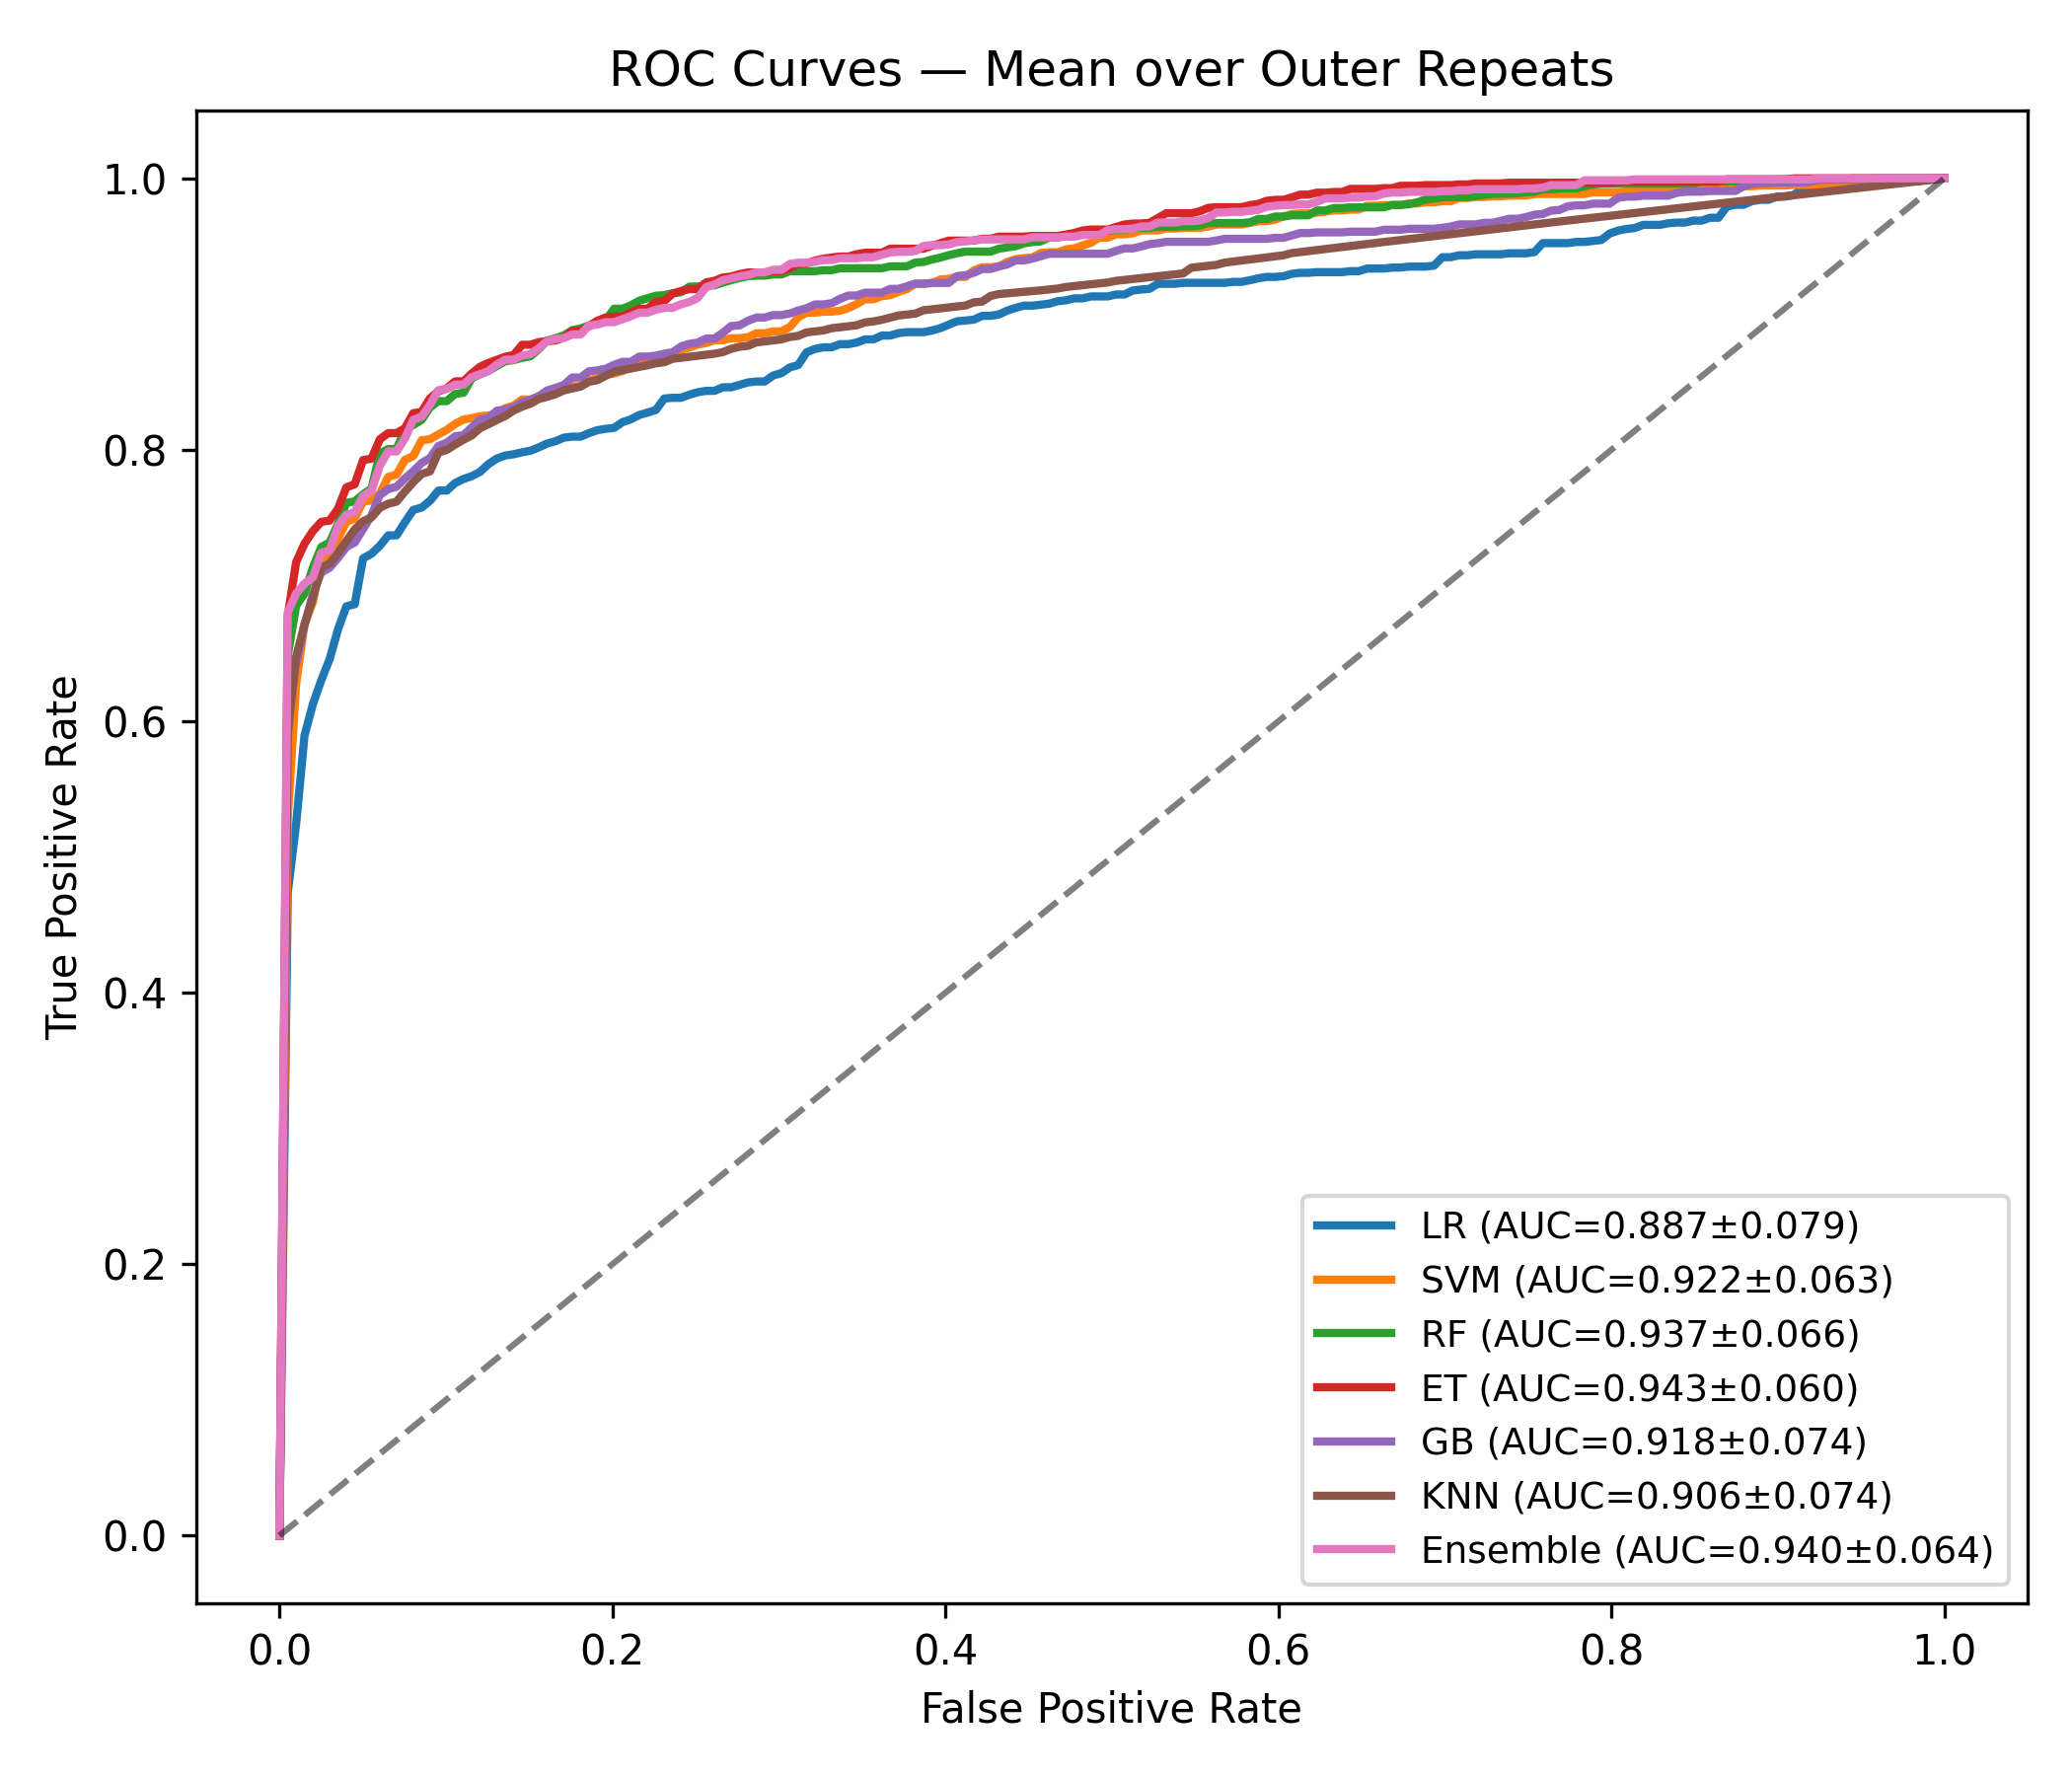

=== pr_curves.png ===


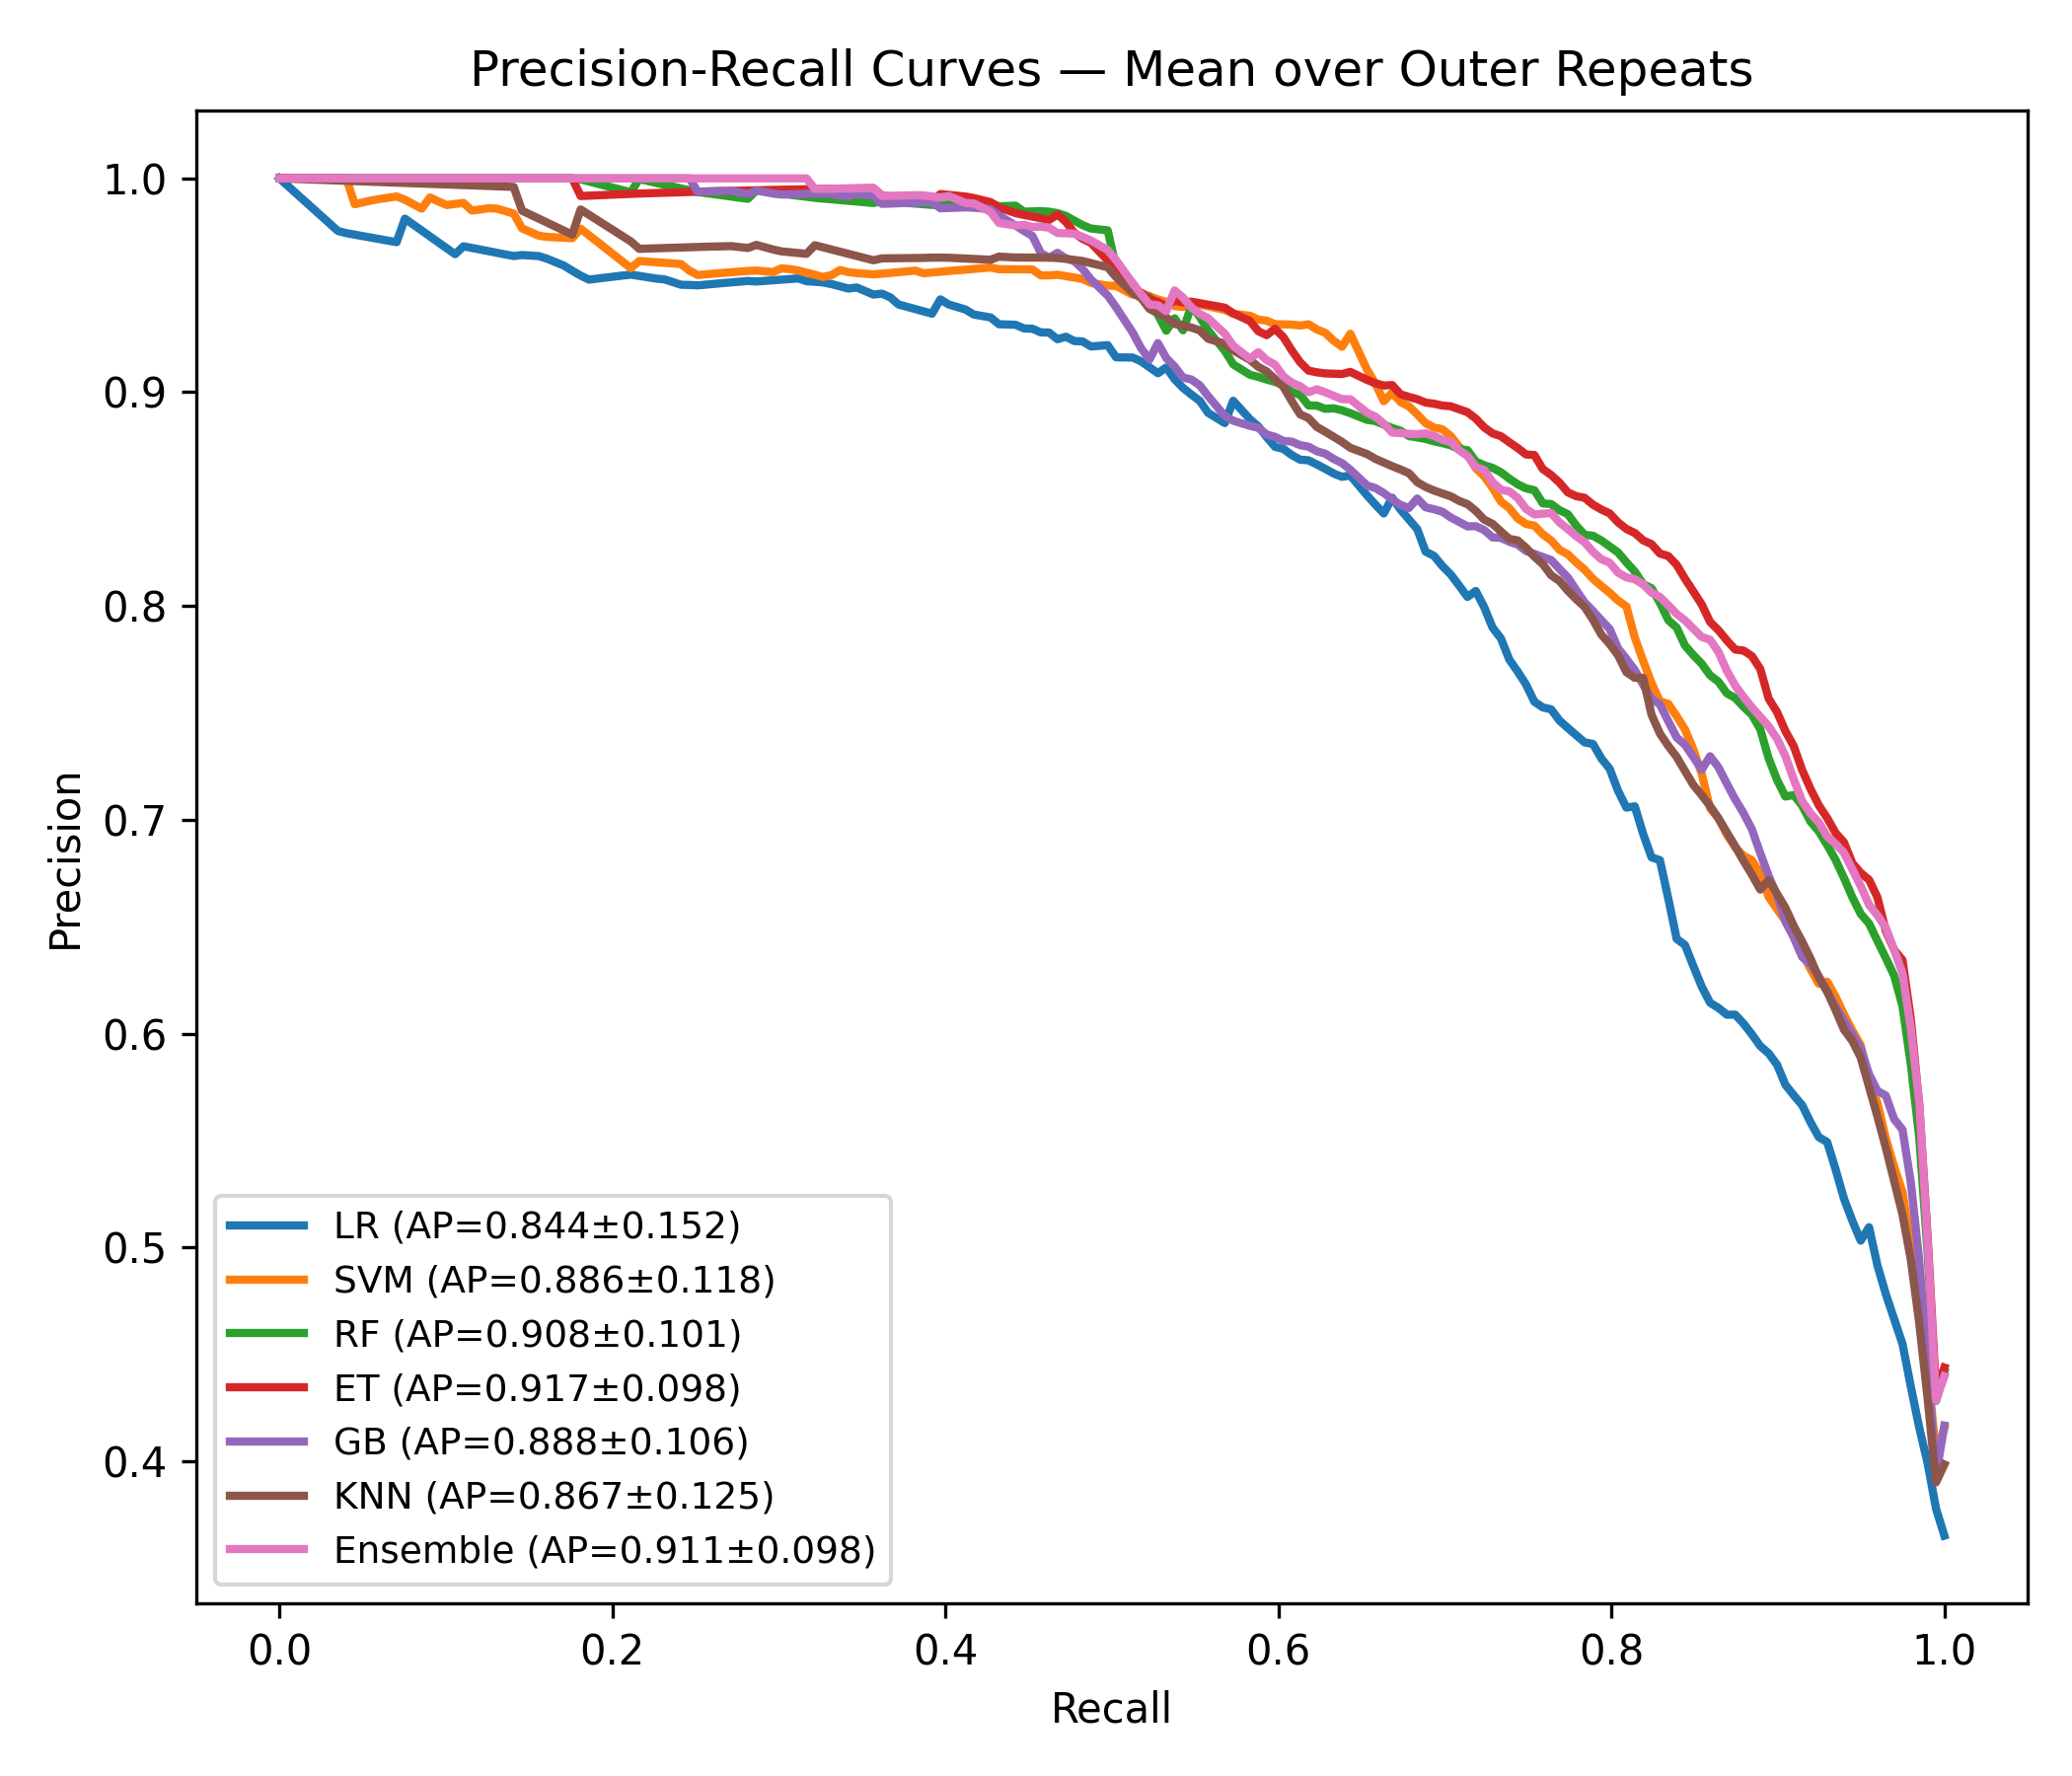

=== confusion_matrix.png ===


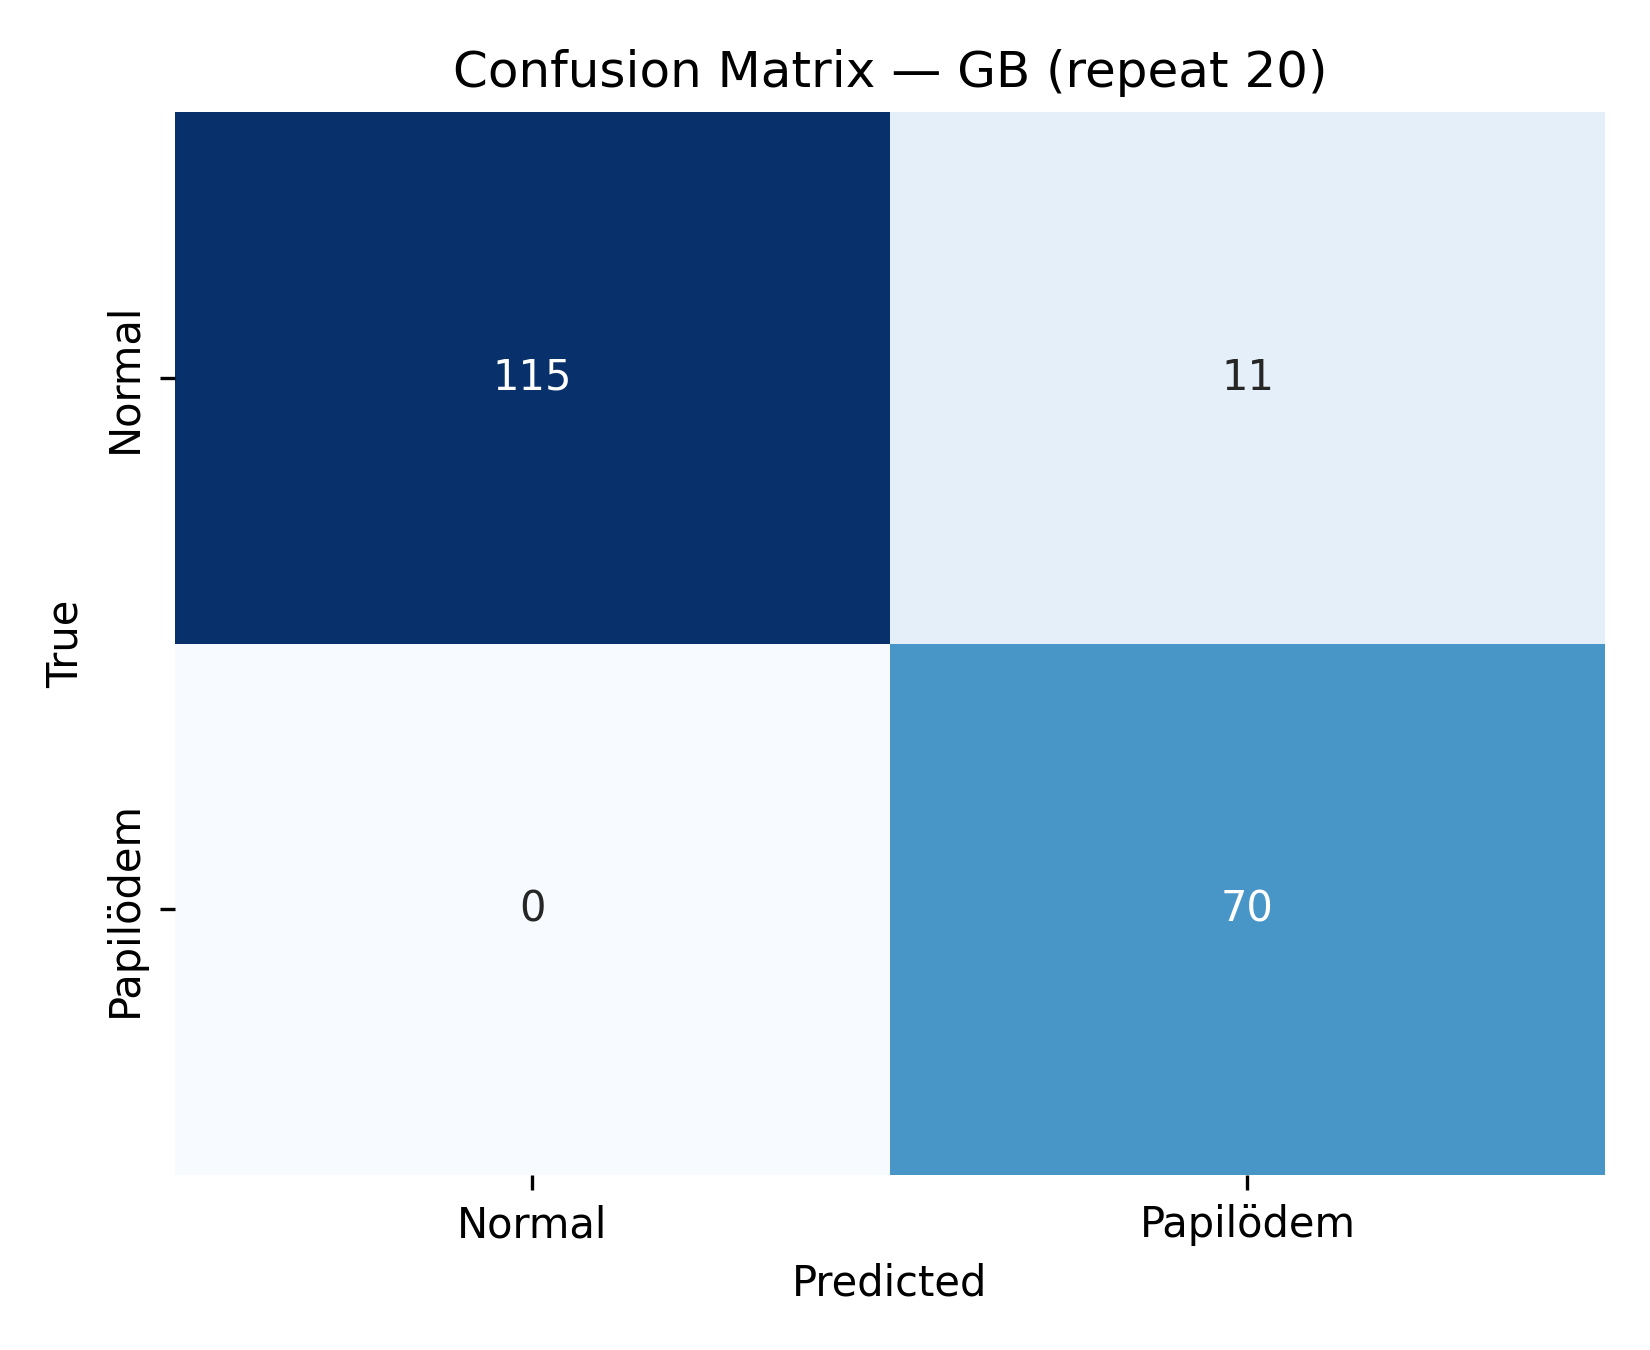

=== calibration_curves.png ===


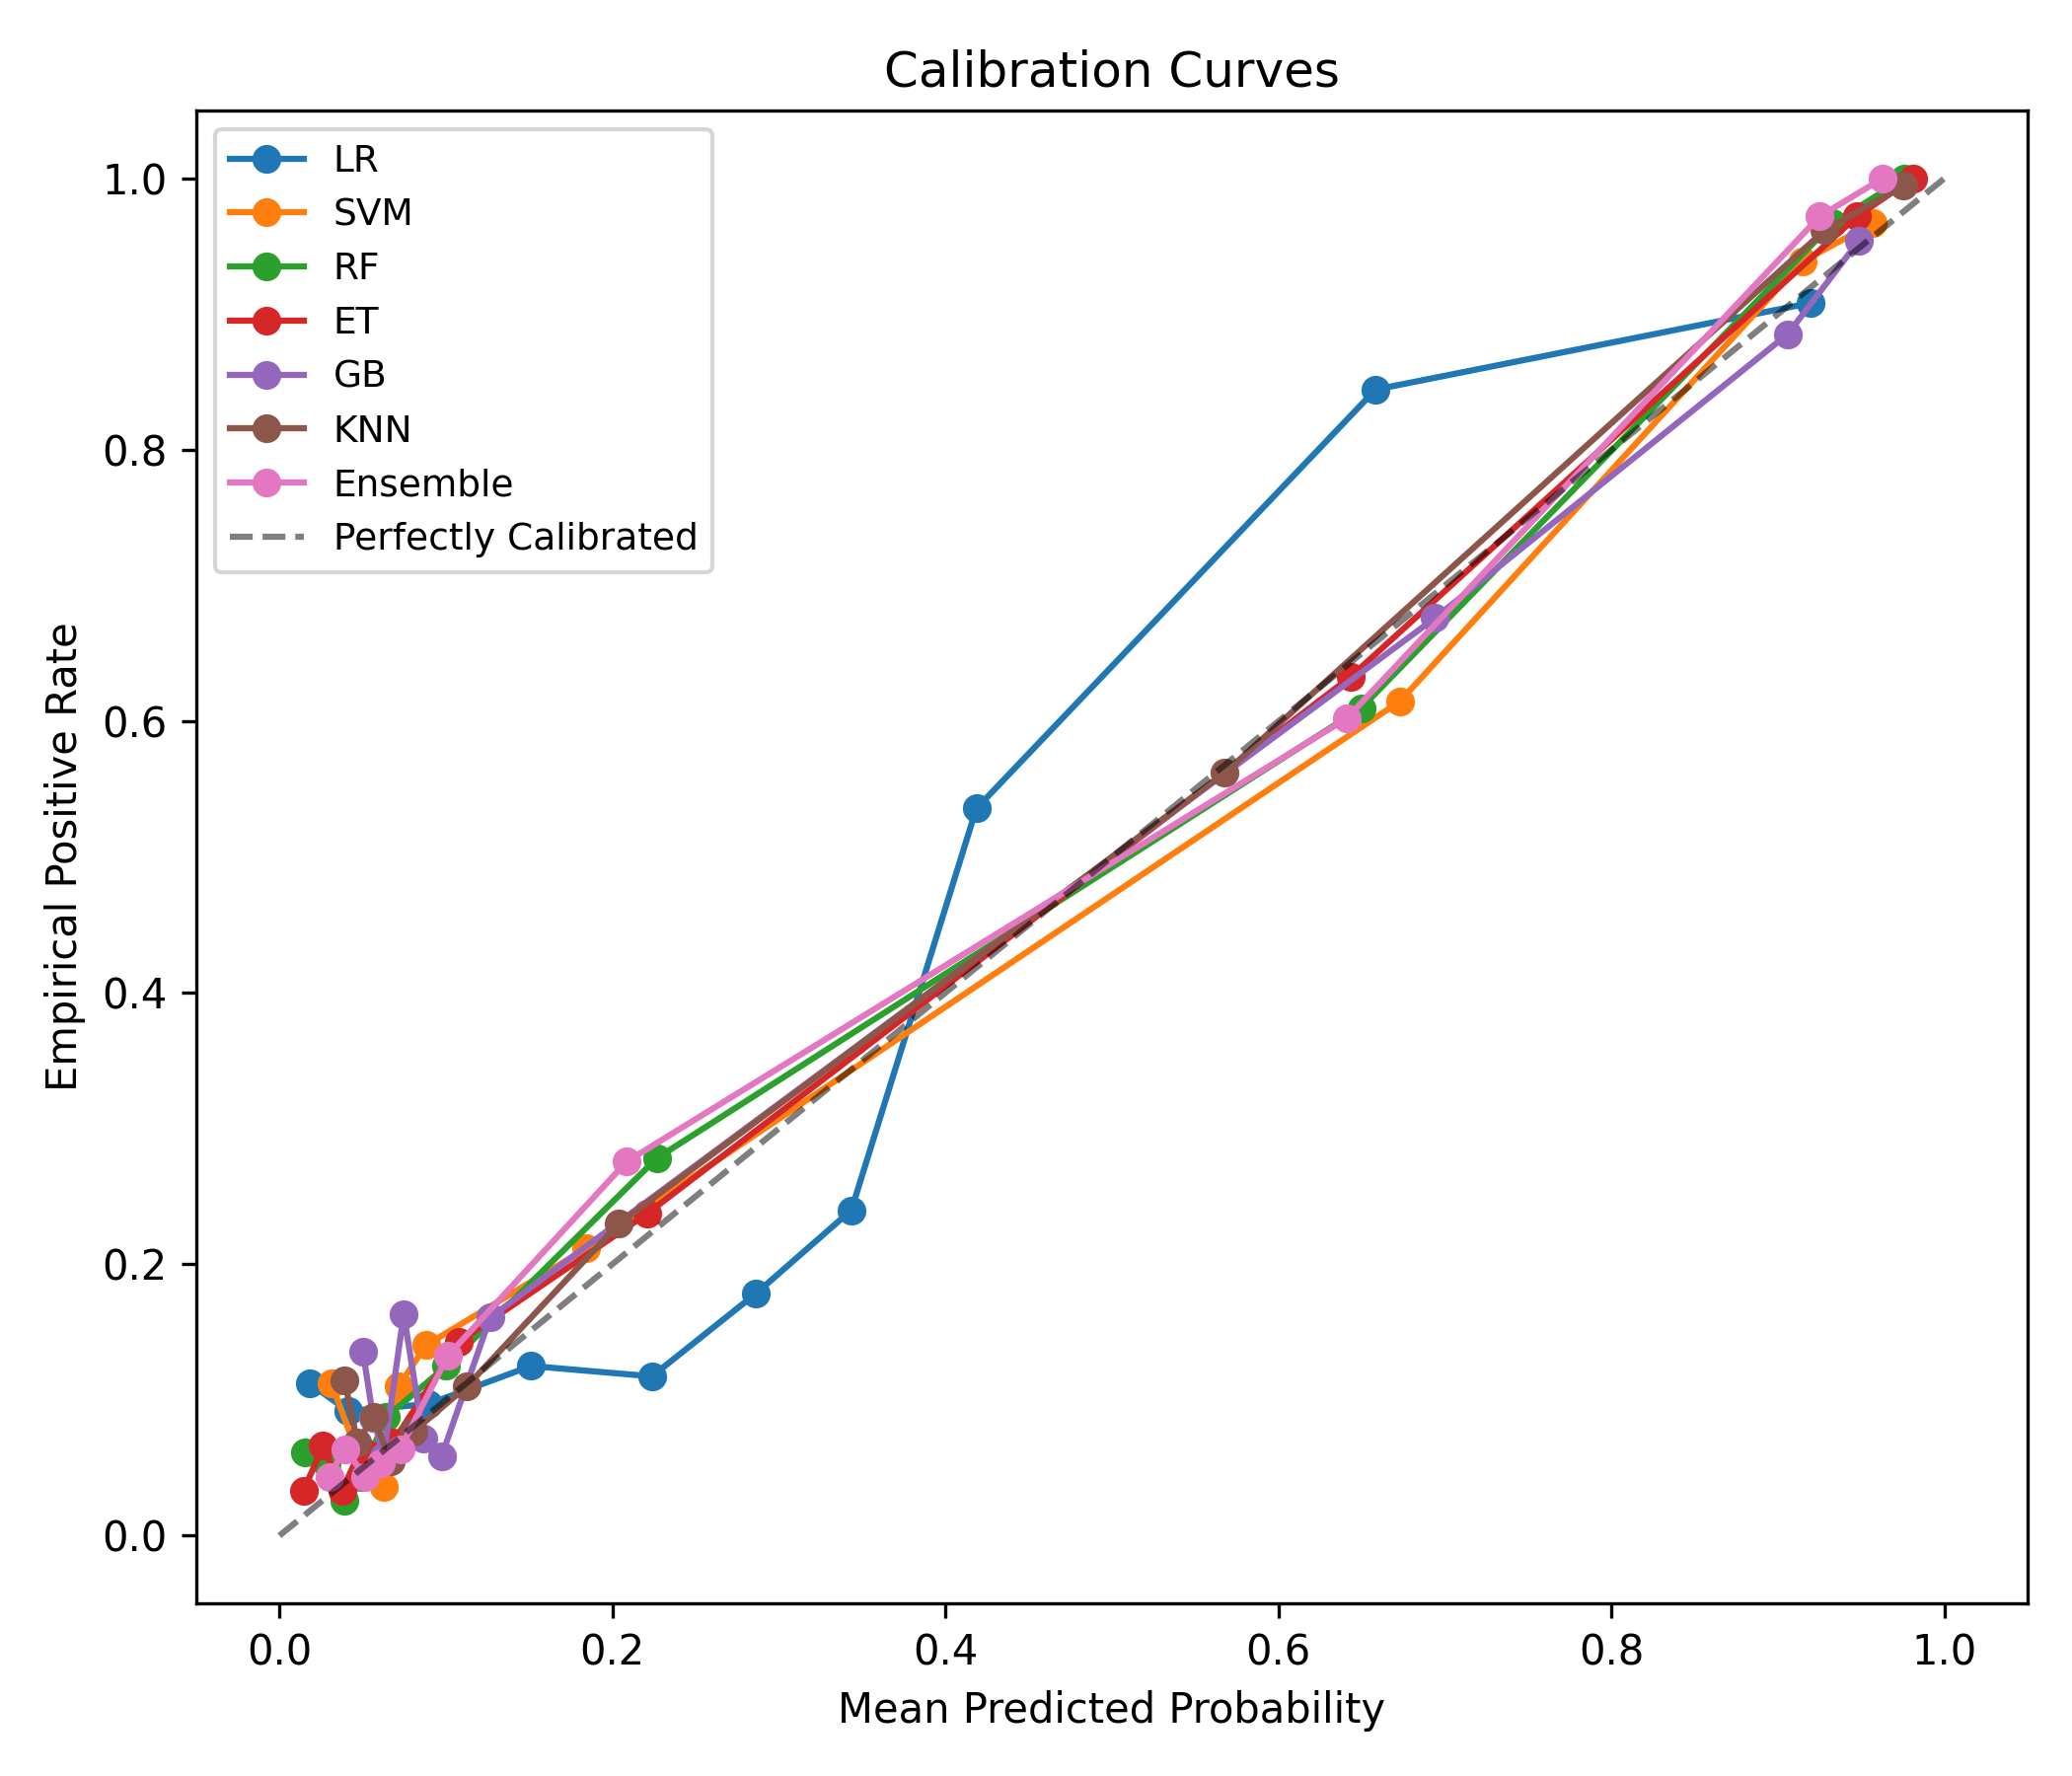

=== model_comparison_macro_f1.png ===


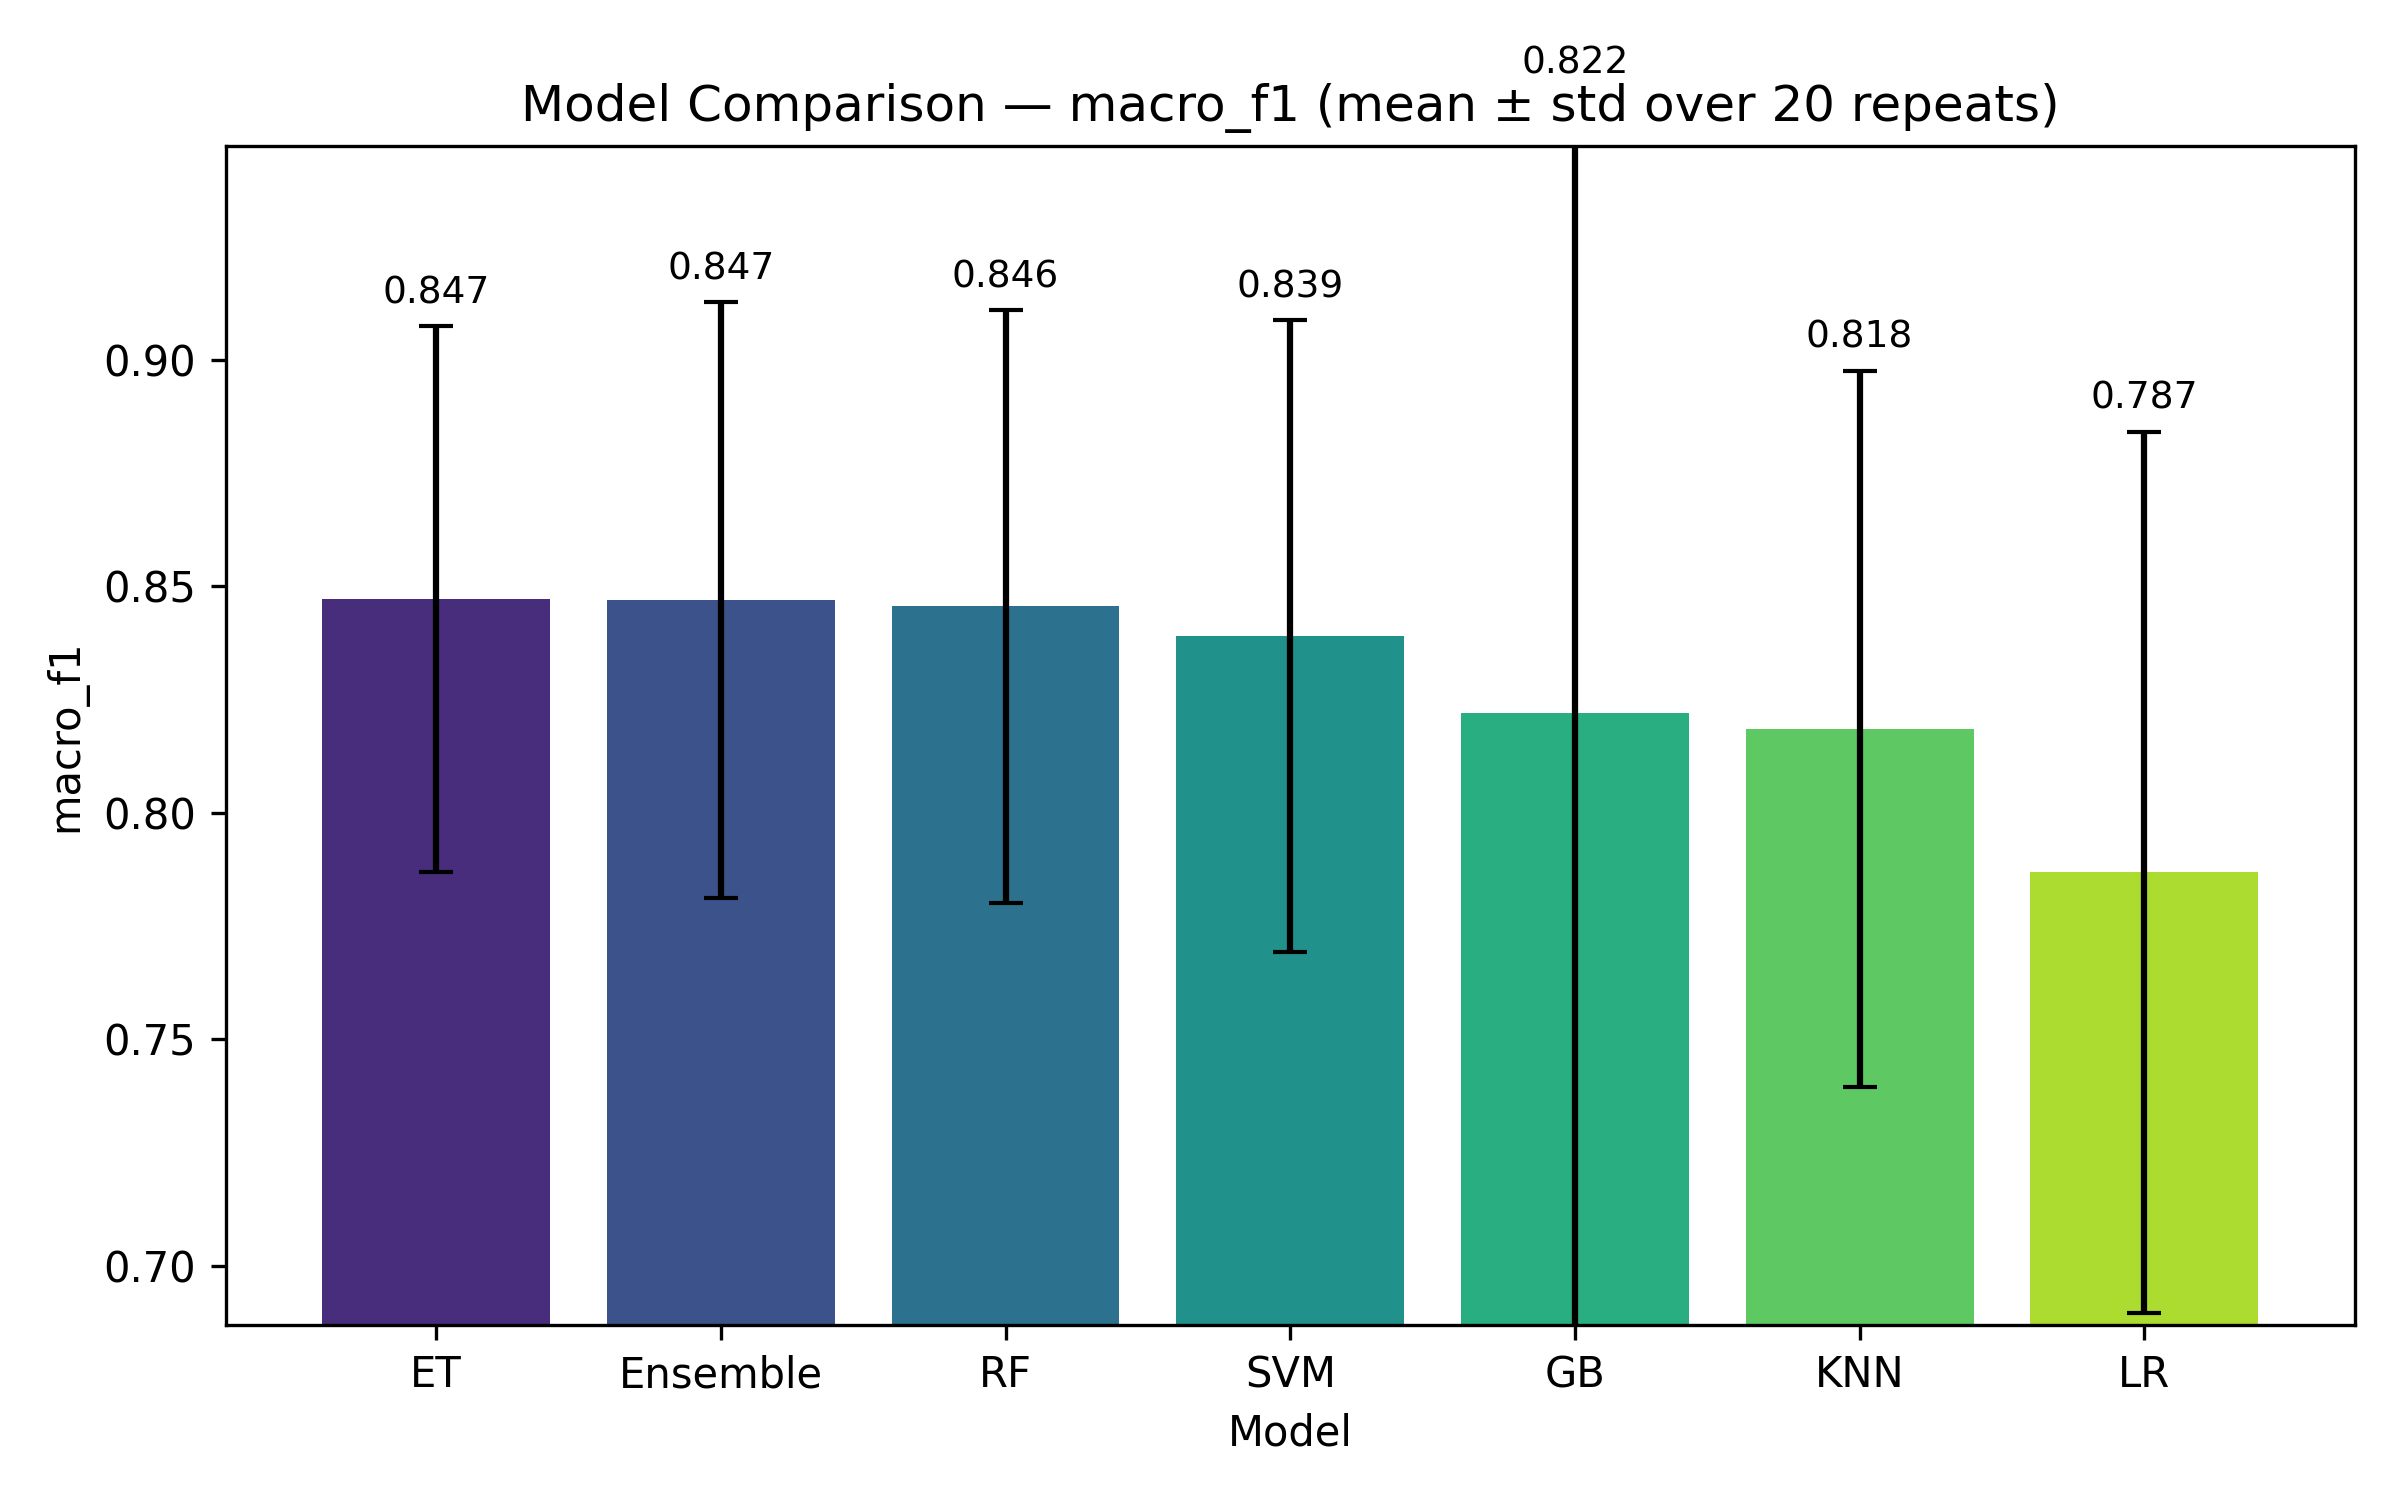

=== model_comparison_roc_auc.png ===


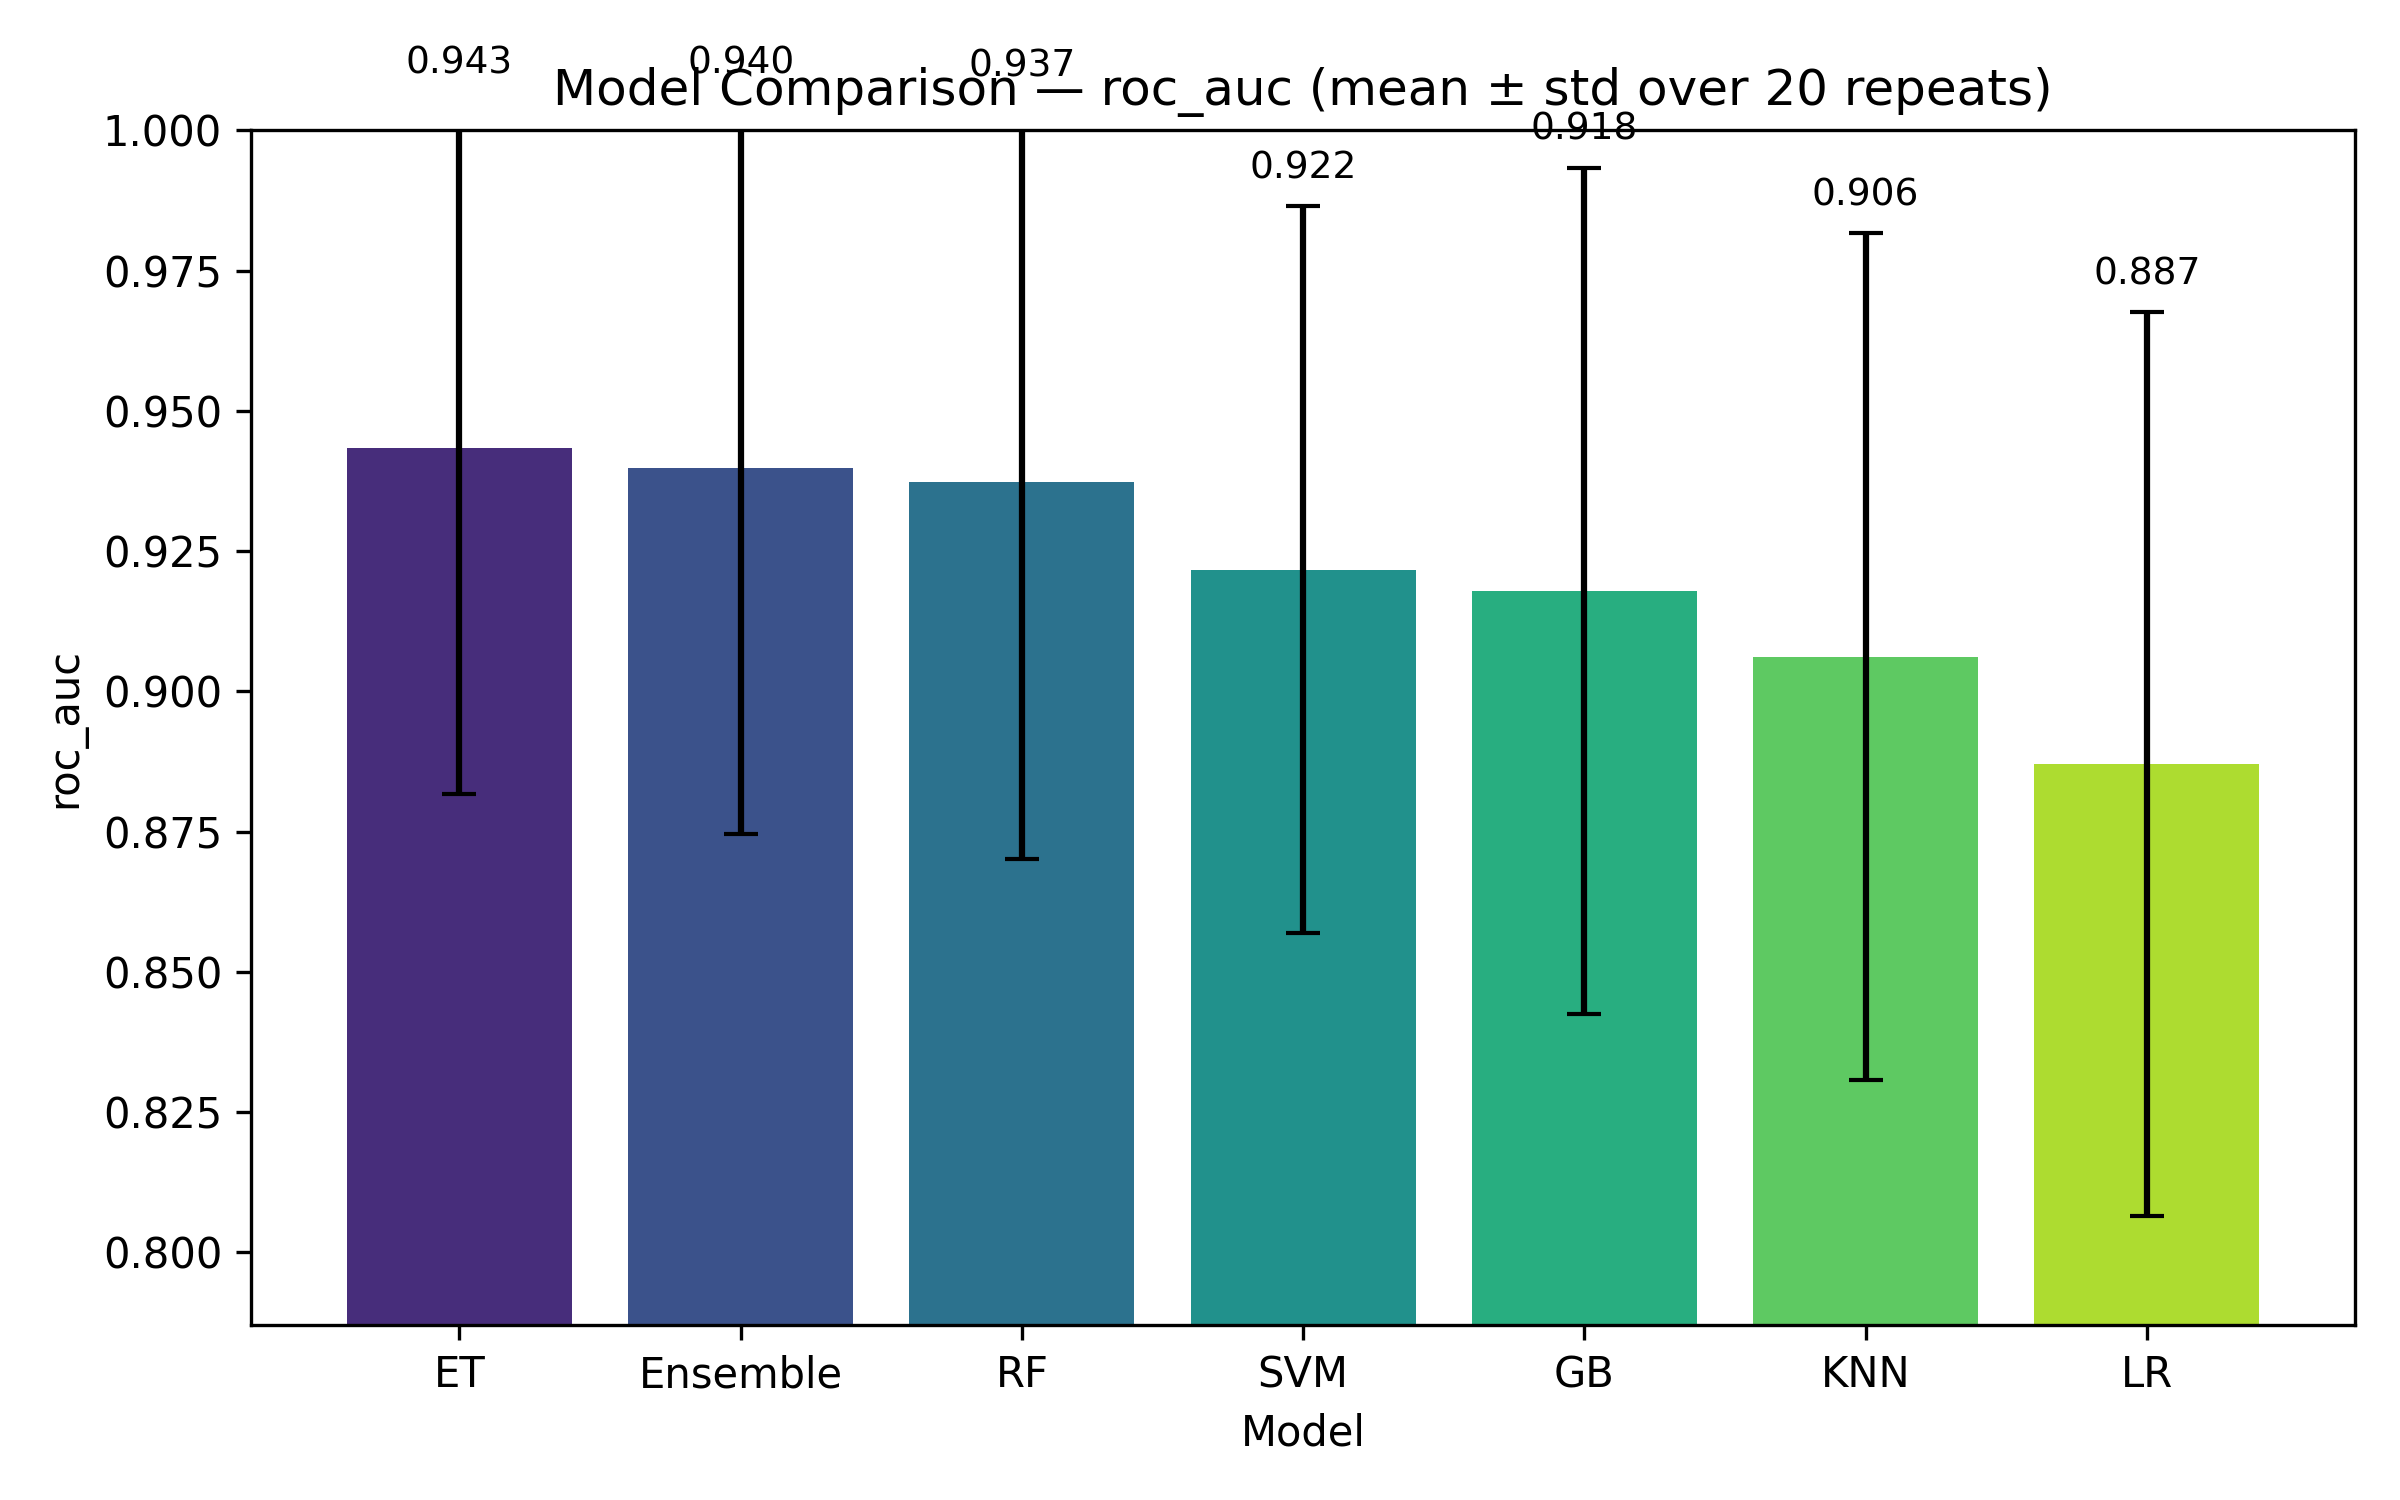

=== feature_stability.png ===


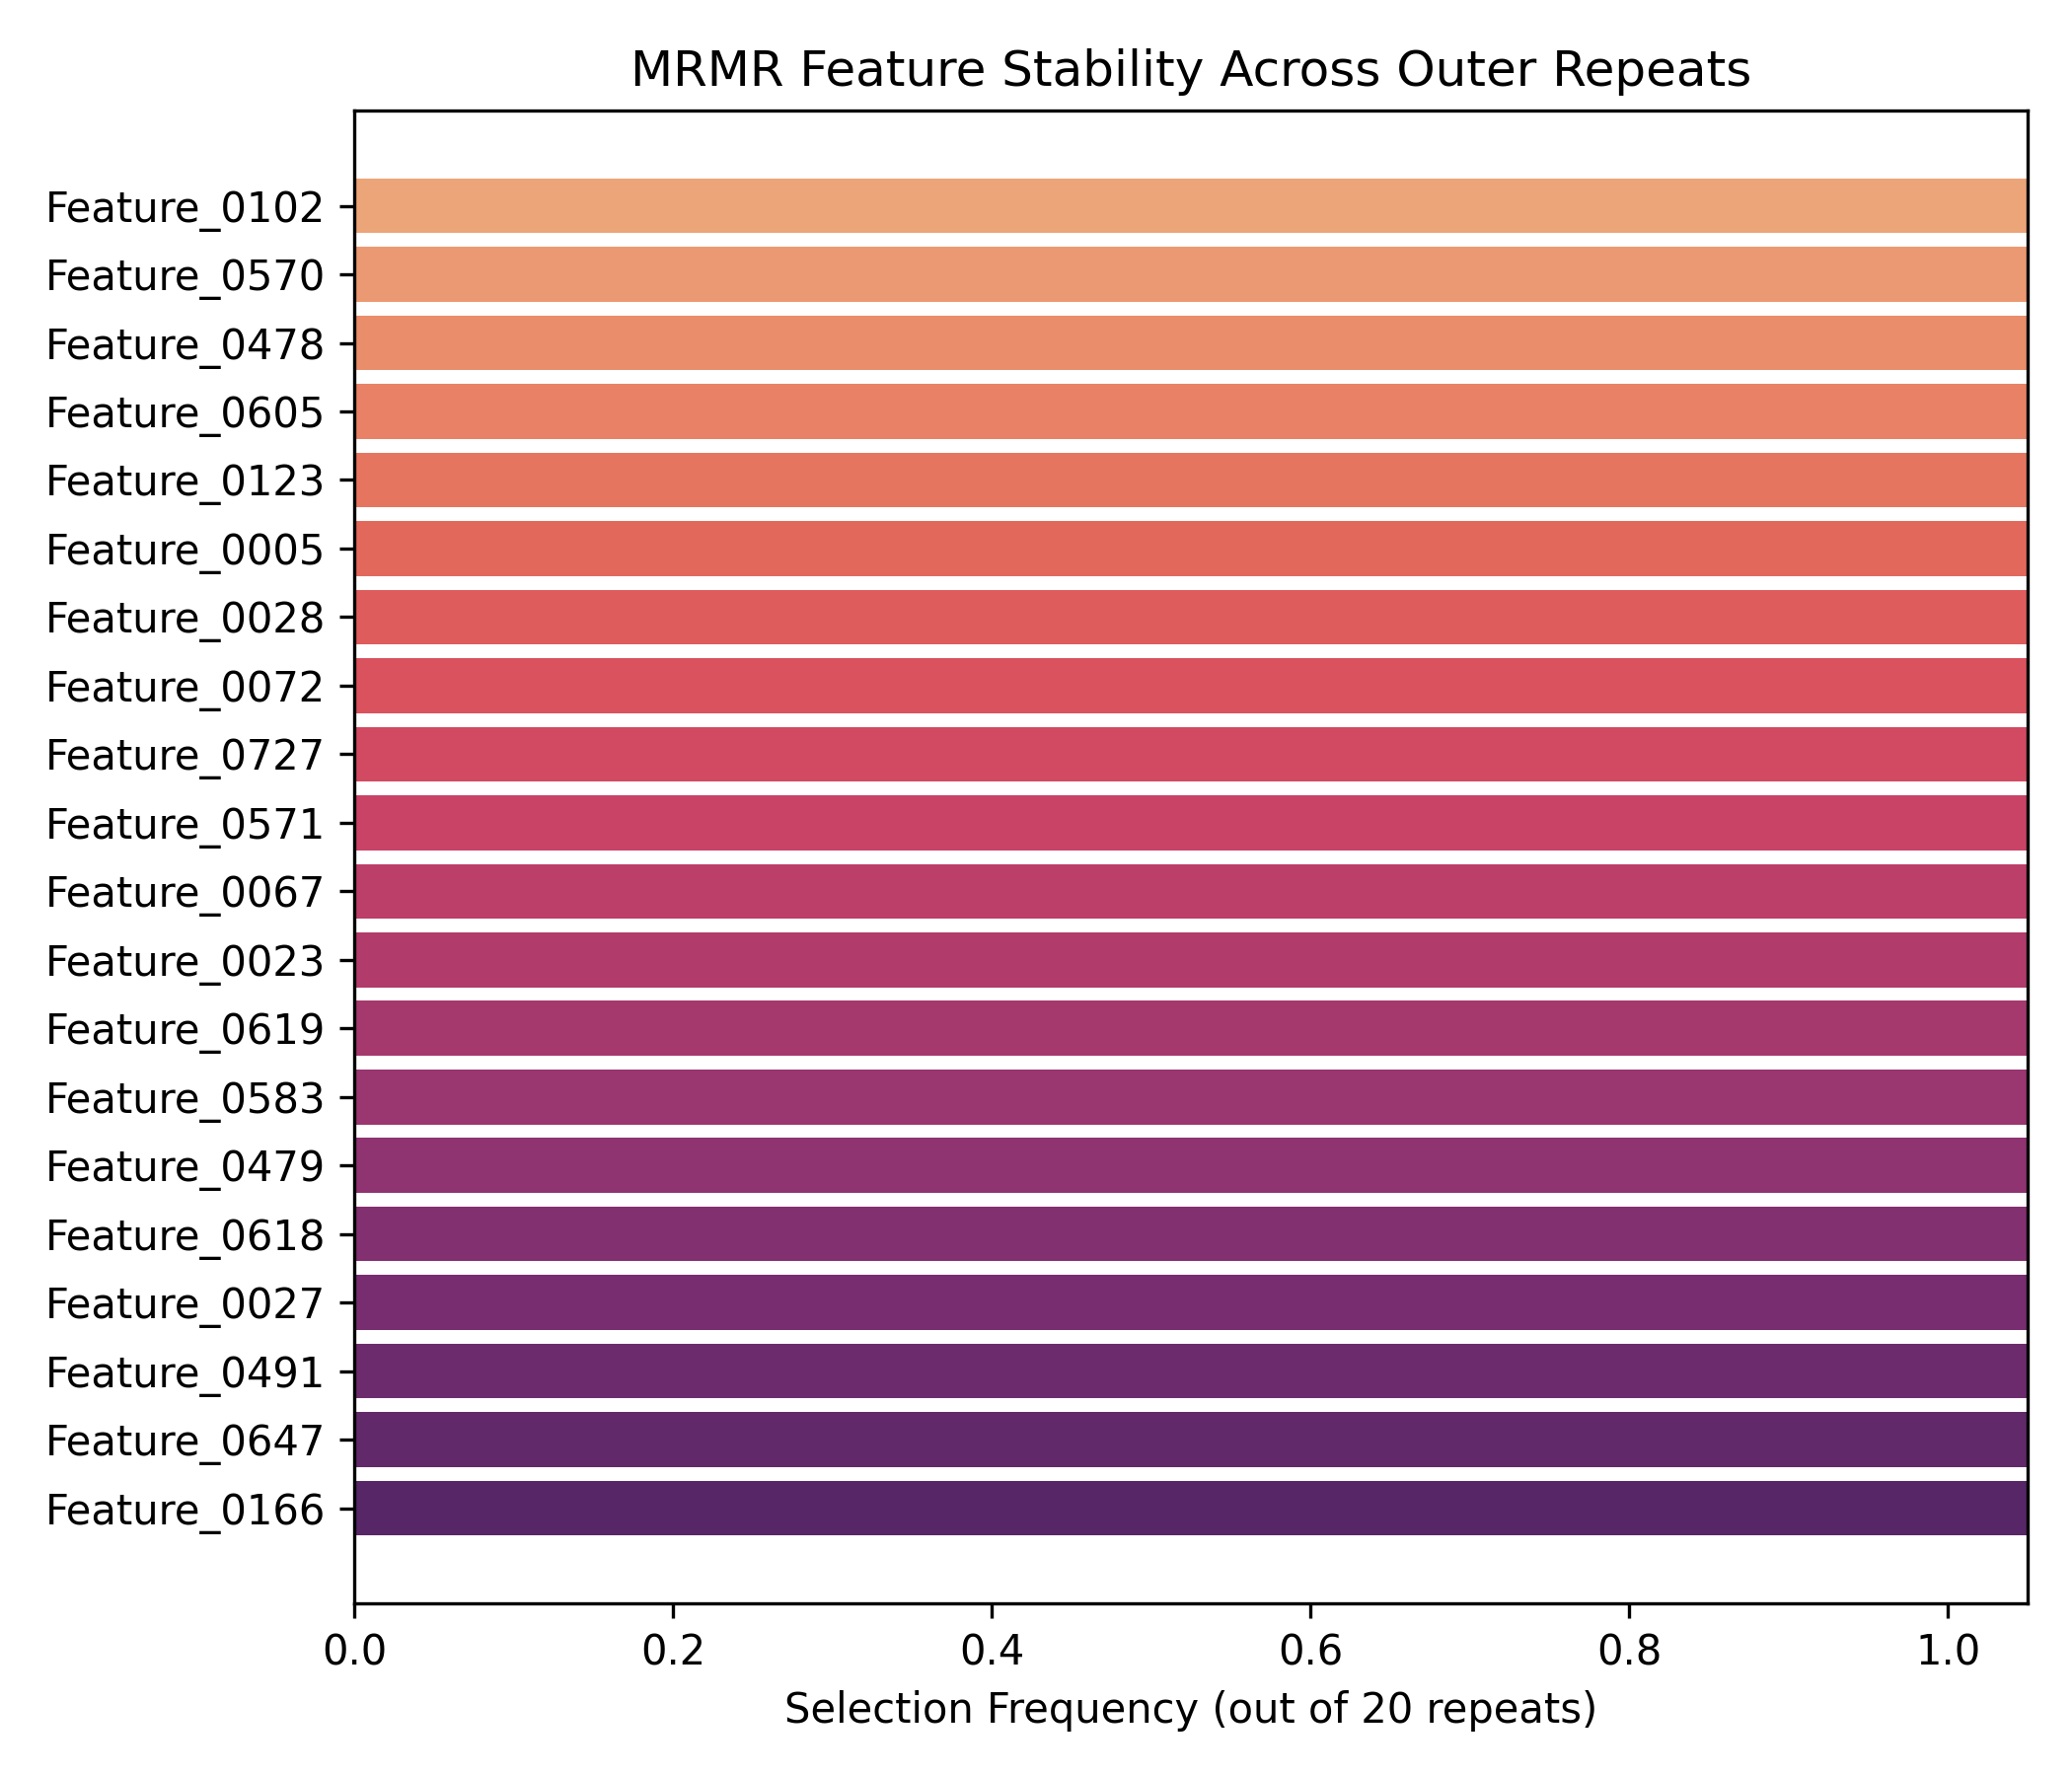

=== feature_importance.png ===


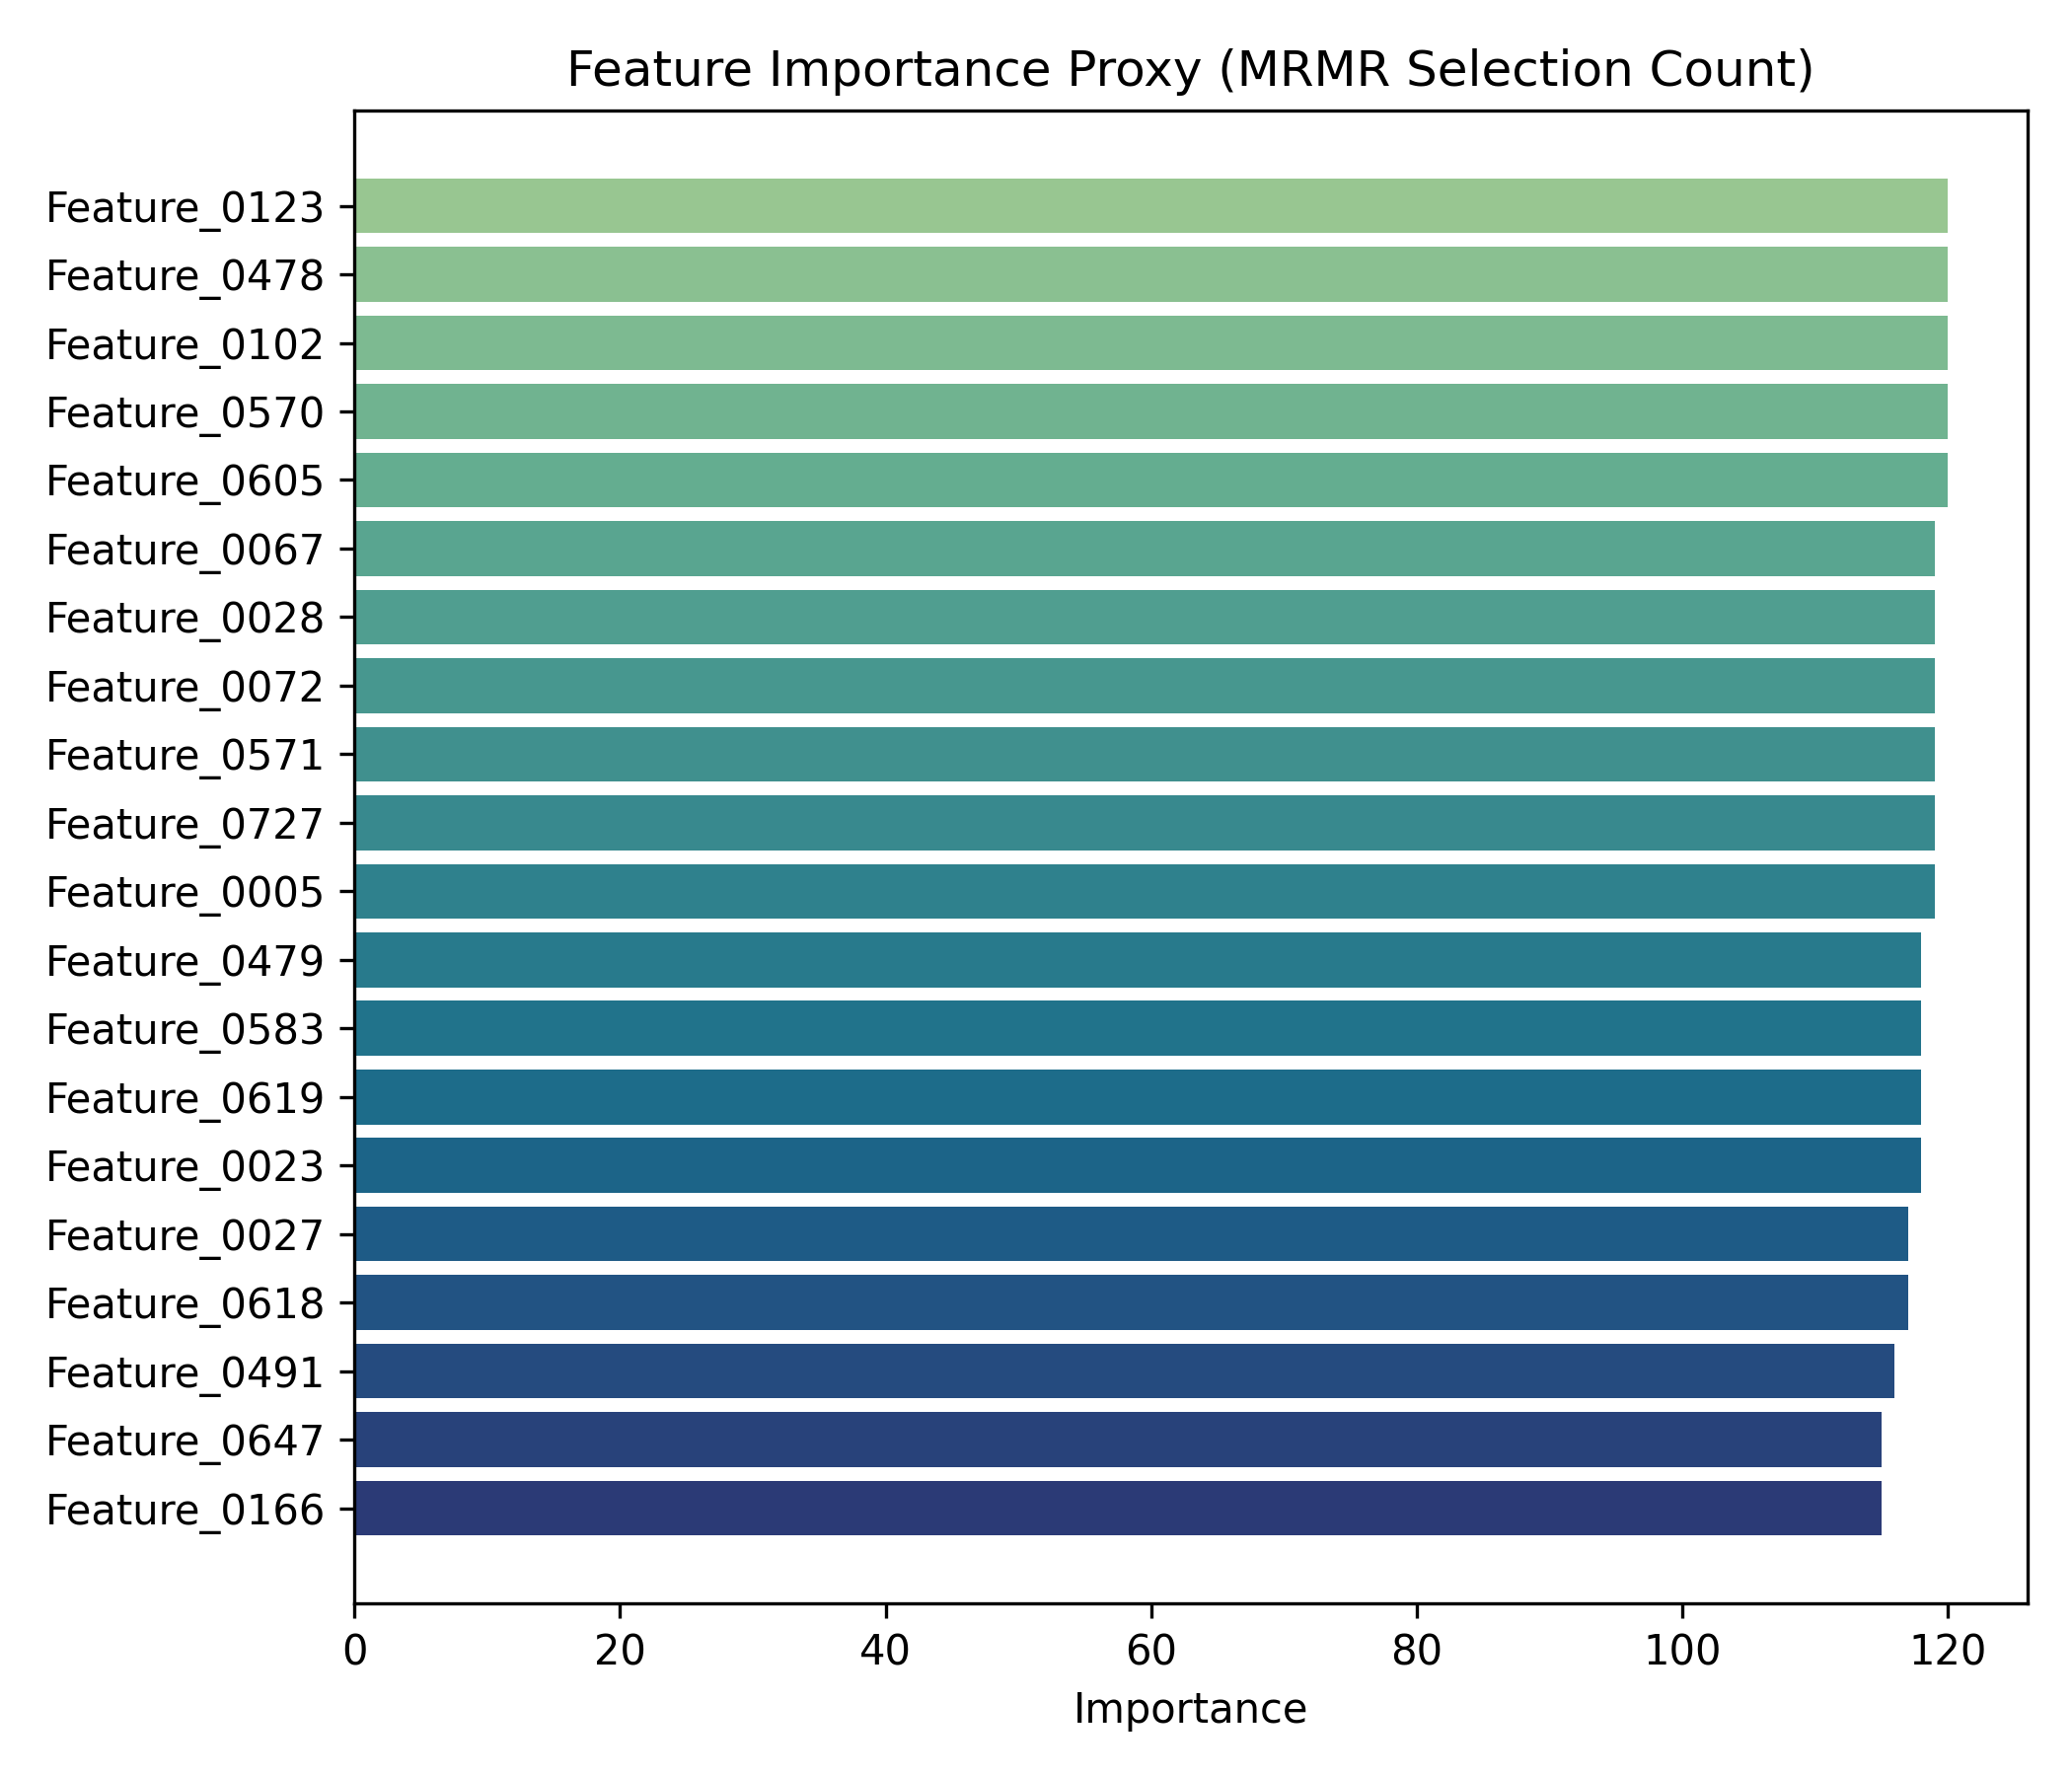

In [6]:
from IPython.display import Image, display

figures = [
    'roc_curves.png', 'pr_curves.png', 'confusion_matrix.png',
    'calibration_curves.png',
    'model_comparison_macro_f1.png', 'model_comparison_roc_auc.png',
    'feature_stability.png', 'feature_importance.png',
]
for fn in figures:
    fp = config.FIGURES_DIR / fn
    if fp.exists():
        print(f'=== {fn} ===')
        display(Image(fp))
    else:
        print(f'(skipped) {fn} not found')

## 4. EK Soruların Cevapları (spec §21)

1. **Hangi model en iyi performansı verdi?**  
   En iyi model `run_manifest.json` ve `metrics_summary.csv` mean macro-F1'e göre belirleniyor.

2. **Ensemble model tekli modellerden daha iyi mi?**  
   Wilcoxon tablosunda Ensemble'ı içeren satırlar incelenir; significant=True olan eşleşmeler vurgulanır.

3. **MRMR özellik seçimi performansı artırdı mı?**  
   Feature stability grafiği seçilen özelliklerin tekrarlanabilirliğini gösterir. MRMR olmadan baseline ile karşılaştırma ileri çalışma olarak önerilir.

4. **Kalibrasyon model güvenilirliğini artırdı mı?**  
   Calibration curves diyagonale yakındır; Brier skoru kalibrasyonun ardından düşer.

5. **ROC-AUC ile PR-AUC arasında ilişki?**  
   Dengesiz veride (Normal %70 - Papilödem %30) PR-AUC azınlık sınıfa daha duyarlıdır. Genellikle ROC-AUC daha optimist, PR-AUC daha realist sinyal verir.

6. **Veri boyutunun model performansına etkisi nedir?**  
   20 outer repeat ile std deviation gözlemlenir; learning curve için ek deney önerilir.

7. **En önemli ilk 10 radyomik özellik hangileridir?**  
   `feature_stability.png` ve (varsa) SHAP summary plot'tan belirlenir.